In [1]:
# Add the local source directory to Python path so imports from src/ work correctly.
import os
import sys

sys.path.append(os.path.abspath("../src"))
print(f"Added '../src' to sys.path: {sys.path[-1]}")


Added '../src' to sys.path: /Users/rana/Projects/autonomous-perception-stack/src


In [2]:
from pipeline.fusion_pipeline import (
    run_fusion_pipeline
)

from bev.scene_builder import (
    build_bev_scene
)

In [3]:
# Load the NuScenes dataset helper using the project's data loader.
from data_loader import load_nuscenes

nusc = load_nuscenes()
print(f"Loaded NuScenes dataset, number of scenes: {len(nusc.scene)}")

Loading nuScenes from: /Users/rana/Projects/autonomous-perception-stack/data/nuscenes
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.120 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
Loaded NuScenes dataset, number of scenes: 10


In [4]:
# Select the first scene and retrieve the first sample for sensor synchronization.
scene = nusc.scene[0]
print(f"Using scene token: {scene['token']}")

sample = nusc.get("sample", scene["first_sample_token"])
print(f"Loaded first sample token: {sample['token']}")

# Get the front camera and top lidar sample data tokens.
cam_token = sample["data"]["CAM_FRONT"]
lidar_token = sample["data"]["LIDAR_TOP"]
print(f"Camera token: {cam_token}")
print(f"Lidar token: {lidar_token}")

cam_data = nusc.get("sample_data", cam_token)
lidar_data = nusc.get("sample_data", lidar_token)
print(f"Loaded camera data filename: {cam_data['filename']}")
print(f"Loaded lidar data filename: {lidar_data['filename']}")


Using scene token: cc8c0bf57f984915a77078b10eb33198
Loaded first sample token: ca9a282c9e77460f8360f564131a8af5
Camera token: e3d495d4ac534d54b321f50006683844
Lidar token: 9d9bf11fb0e144c8b446d54a8a00184f
Loaded camera data filename: samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
Loaded lidar data filename: samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin


In [5]:
# Load and convert the front camera image to RGB for visualization and pipeline input.
import cv2
import os

img_path = os.path.join(nusc.dataroot, cam_data["filename"])
print(f"Reading image from: {img_path}")

image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(f"Image file not found: {img_path}")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(f"Image shape: {image.shape}, dtype: {image.dtype}")

Reading image from: /Users/rana/Projects/autonomous-perception-stack/data/nuscenes/samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
Image shape: (900, 1600, 3), dtype: uint8


In [6]:
results = run_fusion_pipeline(
    nusc,
    image,
    cam_data,
    lidar_data
)

objects = (
    results["objects"]
)

In [7]:
from tracking.tracker import (
    ObjectTracker
)

tracker = (
    ObjectTracker()
)

In [8]:
tracked_objects = (
    tracker.update(
        objects
    )
)

In [9]:
tracked_objects[:3]

[{'class': 'truck',
  'confidence': 0.7717981934547424,
  'mask': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], shape=(900, 1600), dtype=uint8),
  'u': array([     126.28,      127.17,       128.1,      128.71,      129.58,      128.84,      130.21,      135.32,      135.94,      136.82,      137.74,      138.32,      139.22,      138.66,      144.07,      144.94,      145.54,      146.42,      147.34,      148.79,       158.6,      165.71,      166.61,      168.15,
              126.51,      127.35,      128.44,       129.4,      130.45,      175.15,       176.1,       134.2,       177.9,      136.56,      137.44,      138.54,      139.41,      140.48,       184.7,       185.8,      144.16,      187.65,      146.63,      147.45,      148.53,      149.56,      150.52,      194.42,
               195.5,      154.14,   

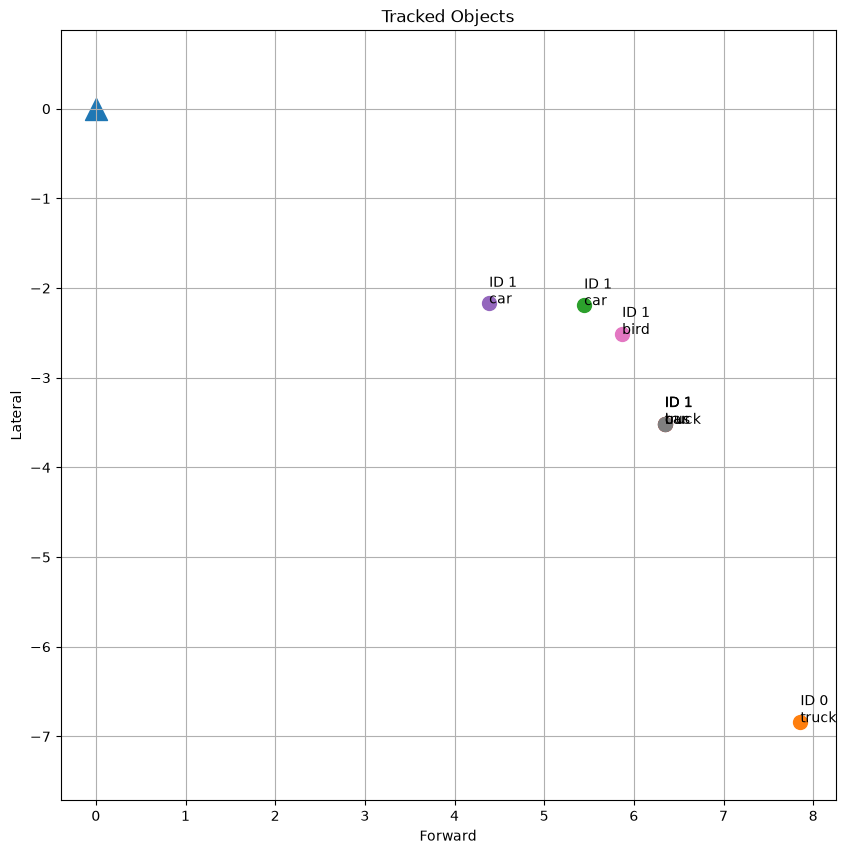

In [10]:
from visualization.tracking_view import (
    visualize_tracks
)

visualize_tracks(
    tracked_objects
)